In [1]:
"""本notebooks基于原来项目中学生自己基于CDA2级及kaggle冷门公开数据集初步制作的数模流程项目,利用coursera平台攻读伊利诺伊大学香槟分校(University of lllinois Uvbana-Champaign)相关课程进行嵌入优化完成.模拟内部审计场景，致力于反欺诈舞弊等真实审计场景,以审计(尤其为内部审计)的视角进行解读,作为大一学生通往大数据和智能审计(内部审计)的成长轨迹见证,作为个人独立完成的项目经历
# 数据集验证URL:https://www.kaggle.com/datasets/kaushalnandania/credit-card-fraud-detection
嵌入伊利诺伊大学香槟分校(University of lllinois Uvbana-Champaign)课程:审计|:审计概念基础+审计||:审计实务和Foundations of strategy internal auditing(战略内部审计基础)作为审计专业理论基础以及UIUC该校会计数据分析专项课程作为会计技术性改进思路
#使用框架参考书目:CDA2级教程量化策略分析(框架主要思路来源) CDA1级教程商业数据分析
逻辑参考书目:审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)  ACCA指定教程F2(MA) Management Accounting ACCA指定教程F3(FA) Financial Accounting
审计逻辑及数据优化逻辑参考课程:UIUC伊利诺伊大学香槟分校(University of lllinois Uvbana-Champaign)课程(通过couursera平台攻读并取得结业证书):
UIUC审计|:审计概念基础+审计||:审计实务和Foundations of strategy internal auditing(战略内部审计基础)作为审计专业理论基础以及UIUC该校会计数据分析专项课程
如有其他引用,已于原notebook中指出"""

"""首先补充并指出审计相关目标框架及程序
# 根据审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第一节P99指出,
# 一般意义上,审计程序是指在审计目标实现过程中对所要获取的审计证据进行收集的详细指标,包括流程,步骤,性质,范围,时限，方法等因素
# 结合该项目模拟情景,应引用审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)对注册会计师对审计程序的定义:
# 在注册会计师中,一般将为获取审计证据所采用的技术方法称为审计程序
# 据审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第一节P100指出
# 总体来说,对于政府审计，内部审计，注册会计师审计3大审计主体及审计准则来说,审计程序均包含审计准备，审计实施，审计终结三大阶段"""

"""本notebook较于原先总体思路及框架大体不变,基于CDA2级教程,主更改方向为思路及专业素养,注释相对变多而且体现审计专业素养,迎合市场趋势"""
from glob import escape#与先前相同,导入必备的库
import numpy as np
import pandas as pd
# import toad(个人环境配置无法使用)
from sklearn.preprocessing import MinMaxScaler

"""一.审计准备阶段(结合据审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第二节准备阶段及审计方案P101~P104)
# 据审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第二节准备阶段及审计方案指出
# 审计准备阶段的主要步骤分为（一）确定审计任务,(二)确定审计标准，(三)组成审计组,（四）签发审计通知书，(五)开展审前调查了解被审计单位及其环境，(六)编制项目审计报告
#审计证据的获取及验证(原为数据读取和统计值汇总)"""
train_df=pd.read_csv(r"C:\Users\范彬\OneDrive\桌面\train.csv")#引用地址为个人习惯地址，可自行更改
print(train_df.head())
train_df.info()
"""审计洞察:假设我作为一个内部审计相关人员,我首先获取了业务系统(或者称为中台系统的原始交易数据或者日志),与数析师相同,同样先查看数据前几行,
# 使用head和info方法来查看变量相关信息,显示信息如下(个人结合CDA数据分析师及审计思维,模拟企业内部审查欺诈及舞弊真实场景):
# 1.员工(数据集)的总体人数(数据集体量或者行数)为1296675人(行),总体人数多,逐个审查难度大,不适用，应依赖于统计及相关模型,而且有虚假欺诈或者被舞弊的员工(脏数据)
# 2.我确定了员工上传提交或者被统计的信息(数据)类型,共计23种员工数据类型(列数),其中有unname的一种可疑信息字段,推测应为员工恶意提交或者提交冗余信息,其中包含交易时间,卡号,员工(商户),类别,金额作为审计使用的关键字段,可结合并用于识别员工异常交易(非法挪用资金等行为),如高额,大额或者非法时间挪用公司资金异常行为,利用行为特征审查出高风险人群
# 3.虽然通过info方法,可看出大体上并无人缺填,但难以避免有员工超时误填或者恶意谎报行为(即存在脏数据),极可能出现提交或者统计信息出现逻辑问题（如amt金额为负,时间格式错误等），导致审查效率低下,故应进行相关的专业处理(数据清洗和相关预处理)
# 结合审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第二节准备阶段P101相关内容,
# 通过审计证据的获取及验证(原为数据读取和统计值汇总)该板块,可以完成审计准备阶段中（一）确定审计任务,(二)确定审计标准
# 在(一）确定审计任务中,审计任务的确定涉及审计目标和审计范围,其中审计目标分为审计总目标,具体目标和项目目标,审计范围分为空间和时间范围
# 根据模拟场景和相关可视化结果得出:审计目标是在企业内部及相关流程现实场景检索并稽查出欺诈人群及舞弊行为,审计范围空间维度上为企业内部,审计范围时间维度项目流程实施
# 在(二)确定审计标准中,审计标准是审计人员判断被审计单位行为是否与其相符的既定尺度
# 在企业内部场景下,应将相关法律法规和方针政策,企业内部自行制定的标准,专业机构研究和制定的行业标准

# 结合审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第二节准备阶段审计方案P104~p105相关内容,指出:
# 审计方案大体分为四个阶段:(一)确定具体审计目标 (二)选择审计范围与重点 (三)在审计准备阶段确定重要性 (四)在审计实施方案中明确审计人员分工,审计时间,审计步骤及方法
# 通过审计证据的获取及验证(原为数据读取和统计值汇总)该板块,可以完成审计准备阶段审计方案中（一）确定具体审计目标,(二)选择审计范围与重点
# 在（一）确定具体审计目标中,审计目标一般是指审计项目目标,具体目标分为一般目标和项目目标。
# 根据模拟场景和相关可视化结果已经得出。(见notebook37行)
# 在(二)选择审计范围与重点中,确定审计范围与重点的方法包括:实地考察法,证据检查法,经验估计法
# 在信息化和大数据时代背景下，根据模拟场景和相关可视化结果得出:该审计方法为证据检查法(风险评估,审计本质的函证功能),经验估计法(智能审计模型)"""

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

'审计洞察:假设我作为一个内部审计相关人员,我首先获取了业务系统(或者称为中台系统的原始交易数据或者日志),与数析师相同,同样先查看数据前几行,\n# 使用head和info方法来查看变量相关信息,显示信息如下(个人结合CDA数据分析师及审计思维,模拟企业内部审查欺诈及舞弊真实场景):\n# 1.员工(数据集)的总体人数(数据集体量或者行数)为1296675人(行),总体人数多,逐个审查难度大,不适用，应依赖于统计及相关模型,而且有虚假欺诈或者被舞弊的员工(脏数据)\n# 2.我确定了员工上传提交或者被统计的信息(数据)类型,共计23种员工数据类型(列数),其中有unname的一种可疑信息字段,推测应为员工恶意提交或者提交冗余信息,其中包含交易时间,卡号,员工(商户),类别,金额作为审计使用的关键字段,可结合并用于识别员工异常交易(非法挪用资金等行为),如高额,大额或者非法时间挪用公司资金异常行为,利用行为特征审查出高风险人群\n# 3.虽然通过info方法,可看出大体上并无人缺填,但难以避免有员工超时误填或者恶意谎报行为(即存在脏数据),极可能出现提交或者统计信息出现逻辑问题（如amt金额为负,时间格式错误等），导致审查效率低下,故应进行相关的专业处理(数据清洗和相关预处理)\n# 结合审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第二节准备阶段P101相关内容,\n# 通过审计证据的获取及验证(原为数据读取和统计值汇总)该板块,可以完成审计准备阶段中（一）确定审计任务,(二)确定审计标准\n# 在(一）确定审计任务中,审计任务的确定涉及审计目标和审计范围,其中审计目标分为审计总目标,具体目标和项目目标,审计范围分为空间和时间范围\n# 根据模拟场景和相关可视化结果得出:审计目标是在企业内部及相关流程现实场景检索并稽查出欺诈人群及舞弊行为,审计范围空间维度上为企业内部,审计范围时间维度项目流程实施\n# 在(二)确定审计标准中,审计标准是审计人员判断被审计单位行为是否与其相符的既定尺度\n# 在企业内部场景下,应将相关法律法规和方针政策,企业内部自行制定的标准,专业机构研究和制定的行业标准\n\n# 结合审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)第6章第二节准备阶段审计方案P104~p105相关内容,指出:\n# 审计方案

在基于结合审计学基础(王会金主编,南京审计大学ACCA班大一下指定用书)观点基础上，
根据伊利诺伊大学香槟分校(University of lllinois Uvbana-Champaign)会计数据分析专项课程1.2.2审计中的高级数据分析中指出:
课程内容介绍了审计领域中高级数据分析如何提升审计效率和效果，特别是通过数据分析技术来支持审计风险模型的建设。
审计关注控制程序的执行情况及财务报表的准确性，提供对内部管理者和外部利益相关者的保证。
内部审计关注企业内部控制的遵守情况，外部审计则关注财务报表是否存在重大错报。
传统审计通过抽样检查交易，现代审计要求对所有交易进行全面评估，寻找控制程序违规情况。
使用数据科学软件和脚本自动化处理大量交易数据，避免Excel处理大数据的局限性和重复劳动。
数据可视化辅助审计通过交互式图表和地图展示交易数据，帮助审计人员快速识别异常和违规模式。
例如，利用地理坐标映射采购卡交易的送货地址，发现非校园地址的异常送货情况。
故借以说明使用数据科学软件如python,R在审计领域的必要性及excel本身的局限性

根据伊利诺伊大学香槟分校(University of lllinois Uvbana-Champaign)课程:审计|:审计概念基础(coursera平台攻读)第3章中指出:
审计风险模型的基本公式：
审计风险（AR）= 内在风险（IR）× 控制风险（CR）× 检测风险（DR）
内在风险（IR）：指财务报表中某项断言本身存在重大错报的可能性，通常由被审计单位的业务性质和环境决定，审计师无法控制。
控制风险（CR）：指被审计单位内部控制未能防止或发现并纠正重大错报的风险。
检测风险（DR）：指审计程序未能发现重大错报的风险，属于审计师可控风险。
审计师通过评估内在风险和控制风险，确定可接受的检测风险，从而设计审计程序。

课程中强调，审计风险模型帮助审计师合理分配审计资源，重点关注高风险领域。
结合本项目中使用kaggle开源去敏冷门信用卡反欺诈类型数据集特征,提出下面个人见解:
内在风险（IR）可以对应于交易本身的风险特征，如交易金额、交易时间、交易地点等。
控制风险（CR）可以对应于客户的账户安全措施、历史欺诈记录、账户活动异常等。
检测风险（DR）则可以对应于模型检测能力，比如模型的误报率、漏报率等。

根据伊利诺伊大学香槟分校(University of lllinois Uvbana-Champaign)课程:审计|:审计概念基础(coursera平台攻读)3.4审计风险模型相关内容
接下来将原版本中notebook区块02_eda开头的风险系数评估调整复现前移至01_audit_preprocessing中,进行IR（内在风险）的量化值

In [2]:
"""此处复现main branch 中02_eda相关"""
# 结合CDA2级教程5.2描述性统计分析思维进行数据探索
# 这里思路借鉴了AUro15kaggle上公开笔记本中的探索分析并加以修改,这里进行风险评估模型相关的风险系数计算
# 一.对主属性(is_fraud)进行单独分析
# 1. 准备数据
# labels = ['amt', 'fraud'] # List format for plotting
# colors = ['#2ecc71', '#e74c3c']
fraud_counts=train_df["is_fraud"].value_counts()#设置风险统计数
fraud_rate=train_df["is_fraud"].mean()#设置风险评估系数

# print(f"风险评估系数为 {fraud_rate:.2%}")
print(f"风险评估系数为 {fraud_rate:.2%},故IR(内在风险)为 {fraud_rate:.2%}")

风险评估系数为 0.58%,故IR(内在风险)为 0.58%


结合Google data analytics 谷歌数据分析证书课程 Analytical thinking for effective outcomes(分析思维以实现有效结果)模块中指出:
分析性思维包括5个模块:1.visualization(可视化) 2.Strategy(策略) 3.Problem-orientation(以问题为导向) 4.Correlation(相关性) 5.Big-picture and detailed-oriented thinking(全局规划),下面应沿用相关思维并结合原notebook02_eda部分风险评估系数对IR(风险系数)进行可视化复现

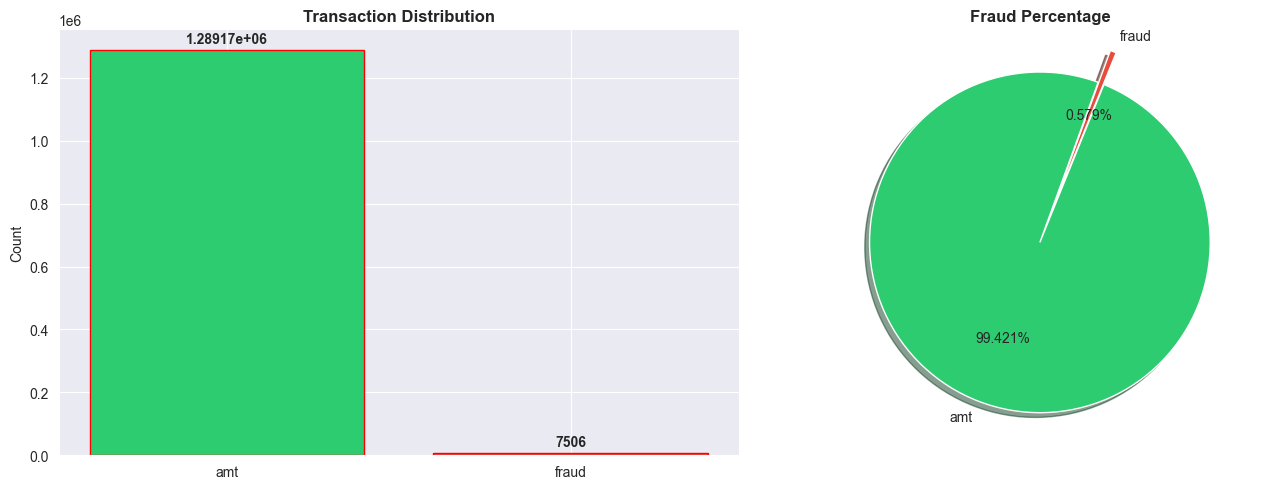

内在风险系数(IR)为 0.58%


In [3]:
"""复现原notebook"""
# 该notebook主要分为数据可视化(分别结合CDA2级教材第5章数据可视化，主要分为matplotlib库和seaborn库)
#导入必备的库
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
train_df=pd.read_csv(r"C:\Users\范彬\OneDrive\桌面\train.csv")  #同上文引用train_dict变量
# 结合CDA2级教程5.2描述性统计分析思维进行数据探索
# 这里思路借鉴了AUro15kaggle上公开笔记本中的探索分析并加以修改,这里进行风险评估模型相关的风险系数计算
# 一.对主属性(is_fraud)进行单独分析
# 1. 准备数据
labels = ['amt', 'fraud'] # List format for plotting
colors = ['#2ecc71', '#e74c3c']
# 2. 设置分窗图布局
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左边图表:条形图
bars = axes[0].bar(labels, fraud_counts, color=colors, edgecolor='red')
axes[0].set_title('Transaction Distribution', fontweight='bold', fontsize=12)
axes[0].bar_label(bars, padding=3, fontweight='bold')
axes[0].set_ylabel('Count')

# 右边图表:饼图
axes[1].pie(fraud_counts, labels=labels, autopct='%1.3f%%', colors=colors,
            startangle=70, explode=(0, 0.2), shadow=True)
axes[1].set_title('Fraud Percentage', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"内在风险系数(IR)为 {fraud_rate:.2%}")
